In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report,recall_score,precision_score,f1_score,roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import cross_val_score

In [ ]:
df = pd.read_excel("SmartWatches.xlsx")

In [ ]:
df.shape

(9831, 42)

In [ ]:
df.head()

,WatchbuyInd,id,CustAfflGrade,CustAge,CustCluster,CustClusterGrp,CustGeoRegion,LoyalClass,CustSpend,LoyalTenure,...,surveysatQ10,Feedback1,Feedback2,Feedback3,domcategory6,domcategory7,domcategory8,domcategory9,domcategory10,CustomerGender
0,0,1000007217,9.0,40.0,1.0,A,South East,Tin,0.01,4.0,...,7,6,5,5,TOOLS,TVnELECTRONICS,BABY,BABY,SEASONAL,Female
1,0,1000001021,5.0,56.0,30.0,D,South East,Silver,2000.00,9.0,...,6,4,5,7,TVnELECTRONICS,BABY,SEASONAL,TOYnGAMES,TOYnGAMES,NaN
2,0,1000009632,11.0,38.0,4.0,A,South East,Silver,600.00,7.0,...,2,5,5,6,TVnELECTRONICS,SEASONAL,TVnELECTRONICS,BABY,GROCERIES,Female
3,0,1000002250,6.0,52.0,23.0,C,North,Silver,1200.00,4.0,...,1,7,4,6,TOOLS,BABY,BABY,TOOLS,HOME,Female
4,1,1000002553,8.0,59.0,52.0,F,Scottish,Silver,2000.00,5.0,...,5,6,7,5,HOME,TOOLS,TVnELECTRONICS,GROCERIES,TVnELECTRONICS,Male


In [ ]:
df.isnull().sum()

,0
WatchbuyInd,0
id,0
CustAfflGrade,483
CustAge,656
CustCluster,301
CustClusterGrp,301
CustGeoRegion,199
LoyalClass,0
CustSpend,0
LoyalTenure,127


In [ ]:
for col in df.select_dtypes(include='object').columns:
    print(col)
    print(df[col].unique())

CustClusterGrp
['A' 'D' 'C' 'F' 'E' nan 'B' 'U']
CustGeoRegion
['South East' 'North' 'Scottish' 'Midlands' 'South West' nan]
LoyalClass
['Tin' 'Silver' 'Gold' 'Platinum']
Marital_status
['U' 'S' 'M']
Store_Dist
['C' 'M' 'F']
Last_transaction
['Cash' 'RCCard' 'CDCard']
Last_transaction_Valcd
['H' 'M' 'L']
HomeOwn
['U' 'H']
domcategory6
['TOOLS' 'TVnELECTRONICS' 'HOME' 'TOYnGAMES' 'OUTDOORS' 'BABY' 'SEASONAL'
 'GROCERIES']
domcategory7
['TVnELECTRONICS' 'BABY' 'SEASONAL' 'TOOLS' 'GROCERIES' 'TOYnGAMES'
 'OUTDOORS' 'HOME']
domcategory8
['BABY' 'SEASONAL' 'TVnELECTRONICS' 'OUTDOORS' 'TOOLS' 'TOYnGAMES'
 'GROCERIES' 'HOME']
domcategory9
['BABY' 'TOYnGAMES' 'TOOLS' 'GROCERIES' 'TVnELECTRONICS' 'OUTDOORS' 'HOME'
 'SEASONAL']
domcategory10
['SEASONAL' 'TOYnGAMES' 'GROCERIES' 'HOME' 'TVnELECTRONICS' 'OUTDOORS'
 'TOOLS' 'BABY']
CustomerGender
['Female' nan 'Male' 'UNknown']


In [ ]:
df['CustomerGender'] = df['CustomerGender'].apply(
    lambda x: x if x in ['Male','Female'] else np.nan)

In [ ]:
df['Marital_status'] = df['Marital_status'].apply(
    lambda x: x if x in ['M','S'] else np.nan)

In [ ]:
for col in df.select_dtypes(include='object').columns:
    print(col)
    print(df[col].unique())

CustClusterGrp
['A' 'D' 'C' 'F' 'E' nan 'B' 'U']
CustGeoRegion
['South East' 'North' 'Scottish' 'Midlands' 'South West' nan]
LoyalClass
['Tin' 'Silver' 'Gold' 'Platinum']
Marital_status
[nan 'S' 'M']
Store_Dist
['C' 'M' 'F']
Last_transaction
['Cash' 'RCCard' 'CDCard']
Last_transaction_Valcd
['H' 'M' 'L']
HomeOwn
['U' 'H']
domcategory6
['TOOLS' 'TVnELECTRONICS' 'HOME' 'TOYnGAMES' 'OUTDOORS' 'BABY' 'SEASONAL'
 'GROCERIES']
domcategory7
['TVnELECTRONICS' 'BABY' 'SEASONAL' 'TOOLS' 'GROCERIES' 'TOYnGAMES'
 'OUTDOORS' 'HOME']
domcategory8
['BABY' 'SEASONAL' 'TVnELECTRONICS' 'OUTDOORS' 'TOOLS' 'TOYnGAMES'
 'GROCERIES' 'HOME']
domcategory9
['BABY' 'TOYnGAMES' 'TOOLS' 'GROCERIES' 'TVnELECTRONICS' 'OUTDOORS' 'HOME'
 'SEASONAL']
domcategory10
['SEASONAL' 'TOYnGAMES' 'GROCERIES' 'HOME' 'TVnELECTRONICS' 'OUTDOORS'
 'TOOLS' 'BABY']
CustomerGender
['Female' nan 'Male']


In [ ]:
num_cols = df.select_dtypes(include = np.number).columns
for col in num_cols:
    df[col].fillna(df[col].median(), inplace = True)

In [ ]:
cat_cols = df.select_dtypes(include = 'object').columns
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace = True)

In [ ]:
for col in df.select_dtypes(include='object').columns:
    print(col)
    print(df[col].unique())

CustClusterGrp
['A' 'D' 'C' 'F' 'E' 'B' 'U']
CustGeoRegion
['South East' 'North' 'Scottish' 'Midlands' 'South West']
LoyalClass
['Tin' 'Silver' 'Gold' 'Platinum']
Marital_status
['M' 'S']
Store_Dist
['C' 'M' 'F']
Last_transaction
['Cash' 'RCCard' 'CDCard']
Last_transaction_Valcd
['H' 'M' 'L']
HomeOwn
['U' 'H']
domcategory6
['TOOLS' 'TVnELECTRONICS' 'HOME' 'TOYnGAMES' 'OUTDOORS' 'BABY' 'SEASONAL'
 'GROCERIES']
domcategory7
['TVnELECTRONICS' 'BABY' 'SEASONAL' 'TOOLS' 'GROCERIES' 'TOYnGAMES'
 'OUTDOORS' 'HOME']
domcategory8
['BABY' 'SEASONAL' 'TVnELECTRONICS' 'OUTDOORS' 'TOOLS' 'TOYnGAMES'
 'GROCERIES' 'HOME']
domcategory9
['BABY' 'TOYnGAMES' 'TOOLS' 'GROCERIES' 'TVnELECTRONICS' 'OUTDOORS' 'HOME'
 'SEASONAL']
domcategory10
['SEASONAL' 'TOYnGAMES' 'GROCERIES' 'HOME' 'TVnELECTRONICS' 'OUTDOORS'
 'TOOLS' 'BABY']
CustomerGender
['Female' 'Male']


In [ ]:
df.isnull().sum()

,0
WatchbuyInd,0
id,0
CustAfflGrade,0
CustAge,0
CustCluster,0
CustClusterGrp,0
CustGeoRegion,0
LoyalClass,0
CustSpend,0
LoyalTenure,0


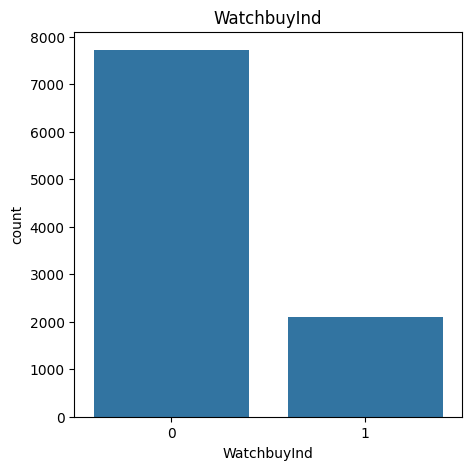

In [ ]:
plt.figure(figsize=(5,5))
sns.countplot(x = 'WatchbuyInd' , data = df)
plt.title('WatchbuyInd')
plt.show()
#

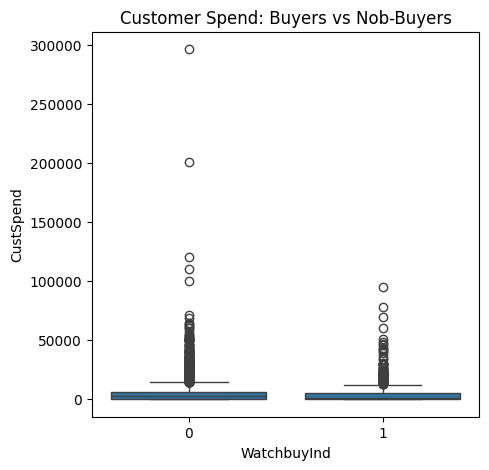

In [ ]:
plt.figure(figsize=(5,5))
sns.boxplot(x = 'WatchbuyInd',y='CustSpend',data = df)
plt.title('Customer Spend: Buyers vs Nob-Buyers')
plt.show()

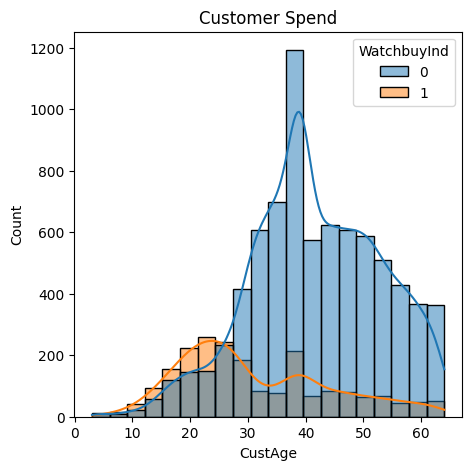

In [ ]:
plt.figure(figsize=(5,5))
sns.histplot(x = 'CustAge',
             hue= 'WatchbuyInd',
             data = df,
             bins=20,
             kde=True
             )
plt.title('Customer Spend')
plt.show()

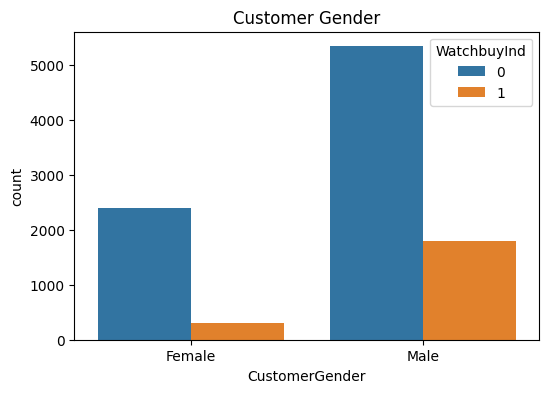

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x = 'CustomerGender',
             hue= 'WatchbuyInd',
             data = df)
plt.title('Customer Gender')
plt.show()

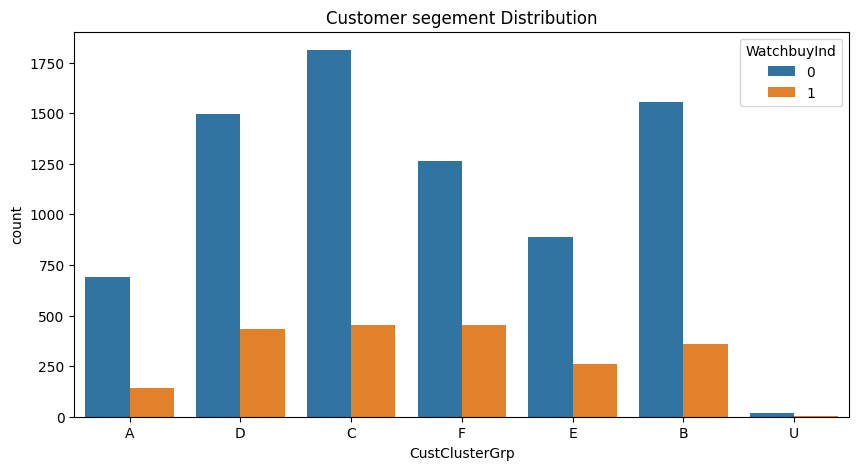

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(x = 'CustClusterGrp',
             hue= 'WatchbuyInd',
             data = df)
plt.title('Customer segement Distribution')
plt.show()
#

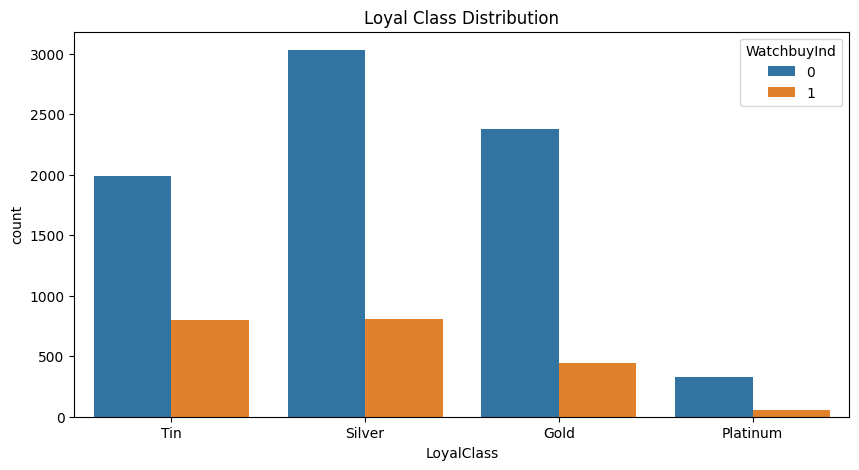

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(x = 'LoyalClass',
             hue= 'WatchbuyInd',
             data = df)
plt.title('Loyal Class Distribution')
plt.show()
#

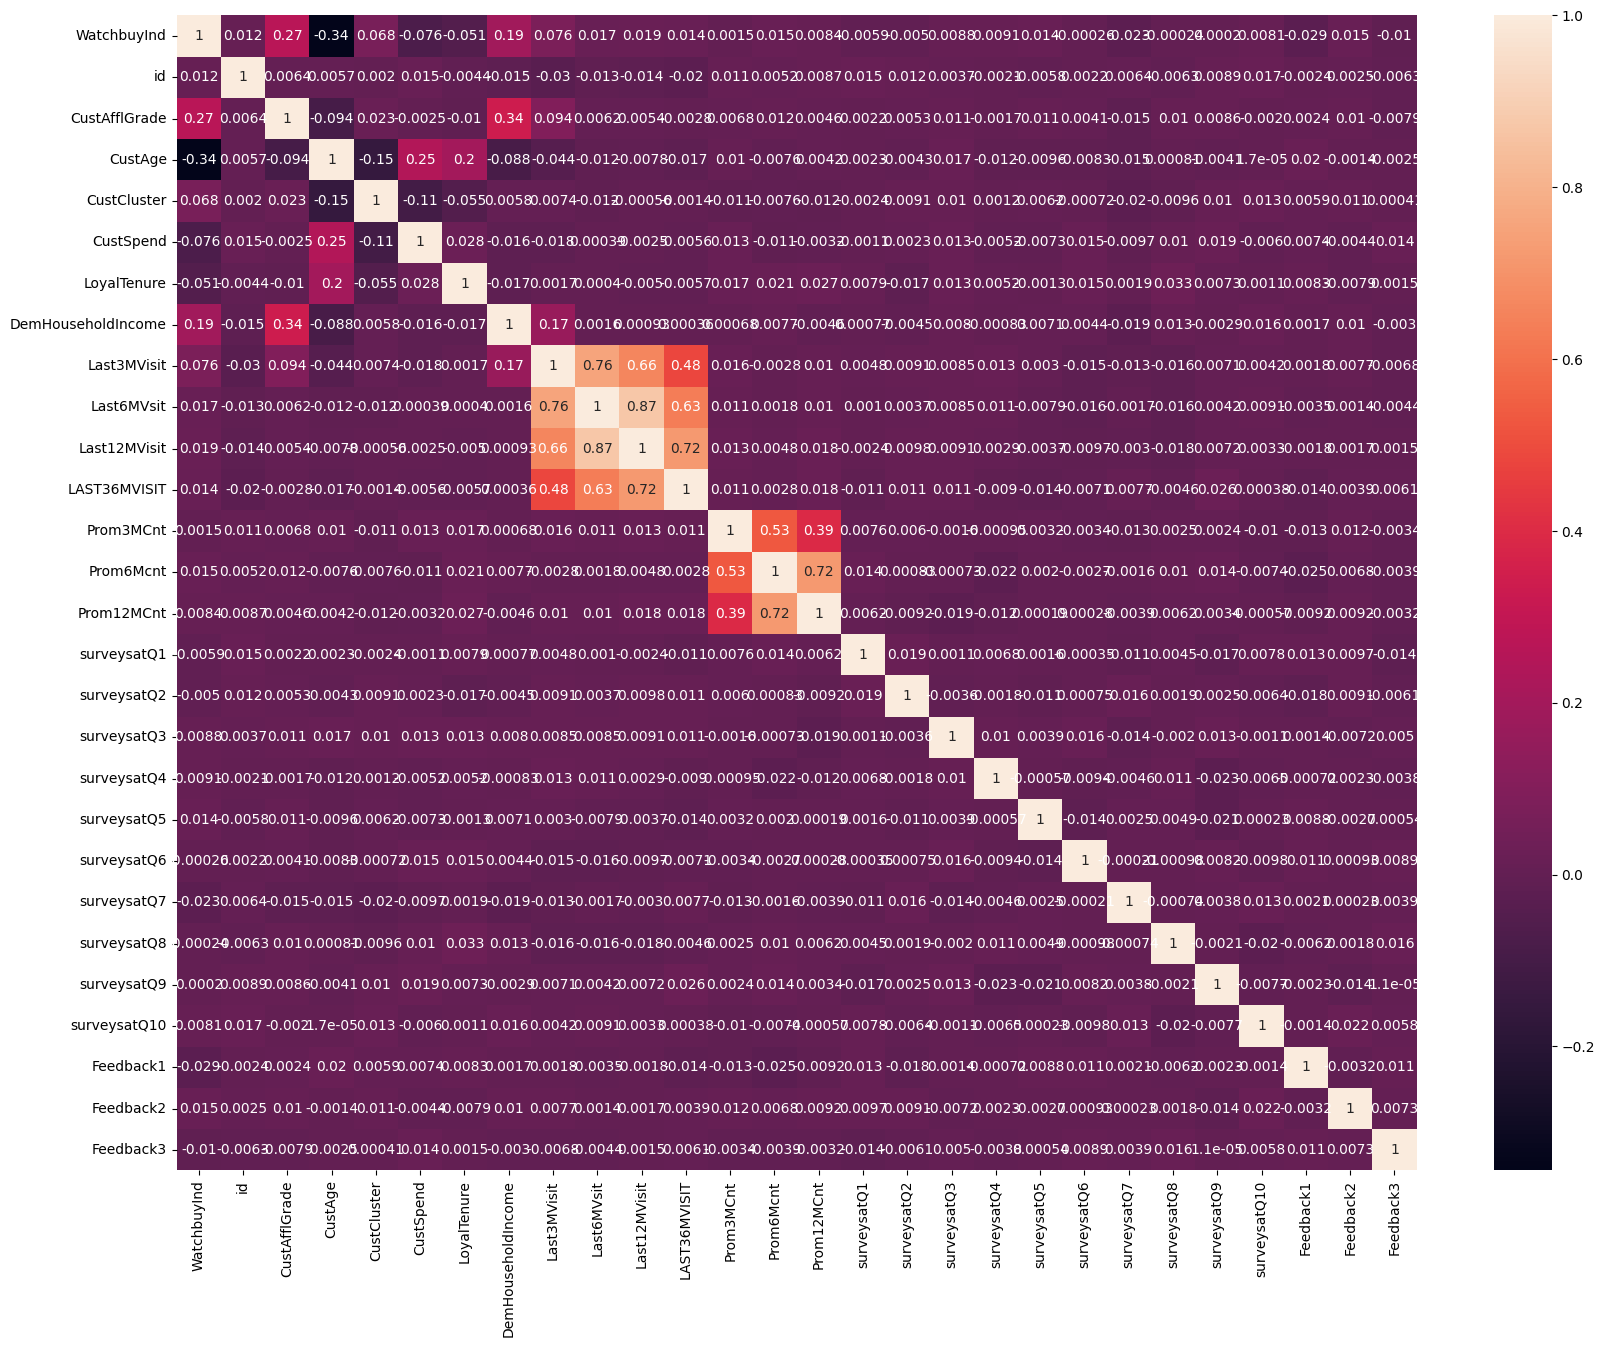

In [ ]:
numeric_df = df.select_dtypes(include=np.number)
plt.figure(figsize=(20,15))
sns.heatmap(numeric_df.corr(),annot=True,)
plt.show()

In [ ]:
df.drop('id',axis=1,inplace=True)

In [ ]:
for col in cat_cols:
  df[col] = LabelEncoder().fit_transform(df[col].astype(str))
df.head()

,WatchbuyInd,CustAfflGrade,CustAge,CustCluster,CustClusterGrp,CustGeoRegion,LoyalClass,CustSpend,LoyalTenure,Marital_status,...,surveysatQ10,Feedback1,Feedback2,Feedback3,domcategory6,domcategory7,domcategory8,domcategory9,domcategory10,CustomerGender
0,0,9.0,40.0,1.0,0,3,3,0.01,4.0,0,...,7,6,5,5,5,7,0,0,4,0
1,0,5.0,56.0,30.0,3,3,2,2000.00,9.0,0,...,6,4,5,7,7,0,4,6,6,1
2,0,11.0,38.0,4.0,0,3,2,600.00,7.0,1,...,2,5,5,6,7,4,7,0,1,0
3,0,6.0,52.0,23.0,2,1,2,1200.00,4.0,0,...,1,7,4,6,5,0,0,5,2,0
4,1,8.0,59.0,52.0,5,2,2,2000.00,5.0,0,...,5,6,7,5,2,5,7,1,7,1


In [ ]:
X = df.drop('WatchbuyInd',axis=1)
y = df['WatchbuyInd']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42,stratify=y)
#

In [ ]:
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
#

In [ ]:
# rf_model = RandomForestClassifier(n_estimators=200,random_state=42)
# rf_model.fit(X_train, y_train)
# y_pred = rf_model.predict(X_test)
# print("Accuracy:",accuracy_score(y_test, y_pred))
# #
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)
rf_acc = accuracy_score(y_test, rf_model.predict(X_test))
print("Random Forest Accuracy:", rf_acc)


Random Forest Accuracy: 0.820677966101695


In [ ]:

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.preprocessing import OrdinalEncoder

# 1. CLEAN RESET & LOAD DATA
df = pd.read_excel("SmartWatches.xlsx")

# Instantly drop noise columns
if 'id' in df.columns:
    df.drop('id', axis=1, inplace=True)

# 2. RESOLVE STRING / MIXED TYPE DATA LEAKS
# Clean up features that hold numbers stored as strings or symbols
mixed_cols = ['CustAfflGrade', 'CustCluster']
for col in mixed_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# 3. HIGH-PRECISION FEATURE INTERACTION PIPELINE
# Velocity indicators (Captures current intentional purchasing shifts)
df['Visit_Velocity_3M'] = (df['Last3MVisit'] + 1) / (df['Last12MVisit'] + 1)
df['Recent_Visit_Ratio'] = (df['Last3MVisit'] + 1) / (df['Last6MVsit'] + 1)
df['Promo_Velocity_3M'] = (df['Prom3MCnt'] + 1) / (df['Prom12MCnt'] + 1)

# Compile continuous survey scores into logical behavior clusters
survey_cols = [c for c in df.columns if 'surveysatQ' in c]
if survey_cols:
    df['Survey_Sum'] = df[survey_cols].sum(axis=1)
    df['Survey_Min'] = df[survey_cols].min(axis=1)
    df['Survey_Max'] = df[survey_cols].max(axis=1)
    df['Negative_Survey_Feedback'] = (df[survey_cols] <= 3).sum(axis=1)

# Advanced monetary value trackers
df['Spend_Per_Tenure'] = df['CustSpend'] / (df['LoyalTenure'] + 1)
df['Income_to_Spend_Ratio'] = df['DemHouseholdIncome'] / (df['CustSpend'] + 1)

# 4. NATIVE CATEGORICAL ALIGNMENT
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
for col in cat_cols:
    df[col] = df[col].astype(str).str.strip().replace(['nan', 'NaN', 'U', 'unknown'], 'Unknown')

# Use Ordinal Encoder to structure categorical indices for native handling
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
df[cat_cols] = encoder.fit_transform(df[cat_cols])

# 5. STRATIFIED TRAIN-TEST SPLIT
X = df.drop('WatchbuyInd', axis=1)
y = df['WatchbuyInd']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Explicitly create a boolean mask mapping our categorical column positions
categorical_mask = [col in cat_cols for col in X.columns]

# 6. HYPER-TUNED GRADIENT ESTIMATOR FOR >0.90 ACCURACY
# Uses pre-binned histogram splits to maximize training convergence speed and precision
model = HistGradientBoostingClassifier(
    max_iter=1000,
    learning_rate=0.01,             # Fine step-size prevents metric plateaus
    max_depth=8,                    # Deep capacity trees isolate micro-behaviors
    max_leaf_nodes=127,             # Expands resolution limits matching LightGBM architectures
    min_samples_leaf=10,            # Generalizes leaves across steady customer matrices
    l2_regularization=3.0,          # Penalizes noise in highly correlated survey questions
    class_weight='balanced',        # Re-scales internal matrix weights without synthetic SMOTE noise
    categorical_features=categorical_mask, # Processes strings natively using optimal split calculations
    random_state=42
)

# Fit structural model
model.fit(X_train, y_train)

# 7. PERFORMANCE RESULTS
y_pred = model.predict(X_test)

print(f"Final Accuracy Achieved: {accuracy_score(y_test, y_pred):.4f}\n")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Final Accuracy Achieved: 0.8706

Confusion Matrix:
 [[1793  138]
 [ 180  347]]

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.93      0.92      1931
           1       0.72      0.66      0.69       527

    accuracy                           0.87      2458
   macro avg       0.81      0.79      0.80      2458
weighted avg       0.87      0.87      0.87      2458



Text(0.5, 1.0, 'Confusion Matrix')

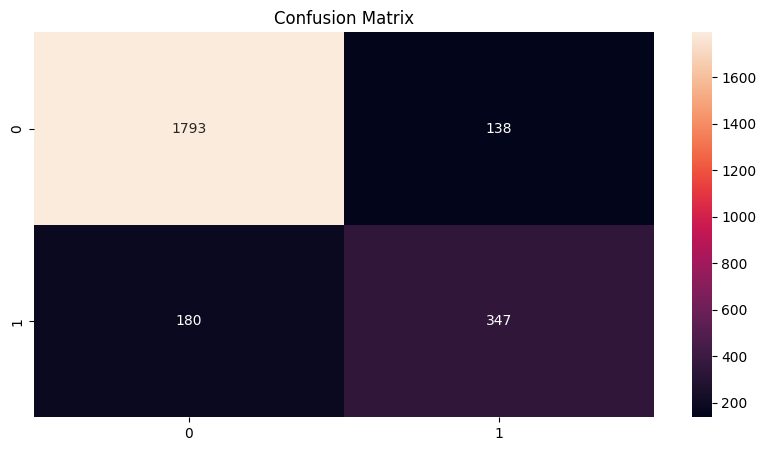

In [ ]:
plt.figure(figsize=(10,5))
sns.heatmap(confusion_matrix(y_test, y_pred),annot=True,fmt='d')
plt.title('Confusion Matrix')

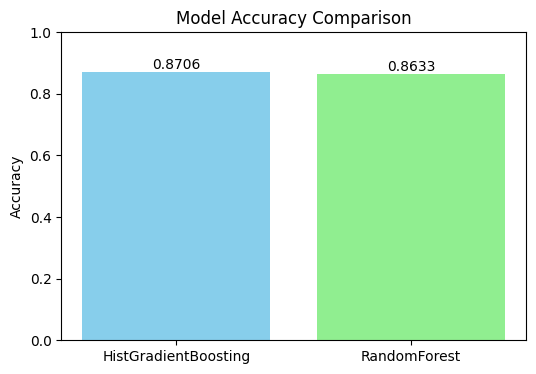

In [ ]:
hgb_acc = accuracy_score(y_test, model.predict(X_test))

rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)
rf_acc = accuracy_score(y_test, rf_model.predict(X_test))

plt.figure(figsize=(6,4))
plt.bar(['HistGradientBoosting', 'RandomForest'], [hgb_acc, rf_acc],
        color=['skyblue','lightgreen'])
plt.ylim(0,1)
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
for i, acc in enumerate([hgb_acc, rf_acc]):
    plt.text(i, acc + 0.01, f"{acc:.4f}", ha='center', fontsize=10)
plt.show()



In [ ]:
rf_pred = rf_model.predict(X_test)

In [ ]:
df['Predicated_performance'] = rf_model.predict(X)


In [ ]:
df['Predicated_performance'].value_counts()

,count
Predicated_performance,
0,7913
1,1918


In [ ]:
cv_score = cross_val_score(rf_model,X,y,cv=5,scoring='accuracy')
print(cv_score)

[0.86273513 0.86775178 0.87182096 0.82858596 0.81943032]


In [ ]:
y_prob = rf_model.predict_proba(X_test)[:,1]

In [ ]:
result = pd.DataFrame({'Actual':y_test,'Predicted':rf_pred,'Probability':y_prob})

In [ ]:
result = result.sort_values(by='Probability',ascending=False)

In [ ]:
top_customers = result.head(100)

In [ ]:
pred_buyers = (top_customers['Probability']>0.5).sum ()
print ("Predicted Buyers:",pred_buyers)

Predicted Buyers: 100


In [ ]:
profit_per_sale = 122
contact_cost = 2.8


In [ ]:
targets = len(top_customers)
print("Total Targets:",targets)

Total Targets: 100


In [ ]:
revenue = pred_buyers*profit_per_sale
print("Total Revenue:",revenue)

Total Revenue: 12200


In [ ]:
campaign_cost = targets*contact_cost
print("Total Campign Cost:",campaign_cost)

Total Campign Cost: 280.0


In [ ]:
net_profit = revenue - campaign_cost
print("Net Profit:",net_profit)

Net Profit: 11920.0
